# **KMeans Clustering  -  Iris Dataset**

## **Importing Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## **Load the Iris Dataset**

In [3]:
iris=load_iris()
X=iris.data
df=pd.DataFrame(X,columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


### **Standardize Features**

In [4]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

### **Determine Optimal number of Clusters**

In [5]:
# Elbow Method

inertia = []
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

* inertia.append(kmeans.inertia_)

The inertia value (sum of squared distances between points and their nearest cluster center) is recorded for each k and added to the list.

In [6]:
# Print inertia values

for i, val in enumerate(inertia,start=1):
    print(f"Number of clusters = {i}, Inertia = {val:.2f}")

Number of clusters = 1, Inertia = 600.00
Number of clusters = 2, Inertia = 222.36
Number of clusters = 3, Inertia = 191.02
Number of clusters = 4, Inertia = 114.35
Number of clusters = 5, Inertia = 91.05
Number of clusters = 6, Inertia = 81.55
Number of clusters = 7, Inertia = 80.78
Number of clusters = 8, Inertia = 64.43
Number of clusters = 9, Inertia = 55.71
Number of clusters = 10, Inertia = 51.12


Inertia decreases as clusters increase.

The sharp drop happens until around k = 3, after which the improvement becomes smaller.
→ That’s why 3 clusters is considered optimal.

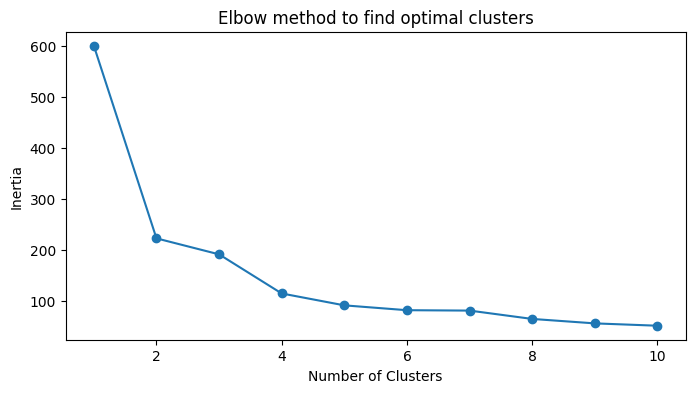

In [7]:
# Plot

plt.figure(figsize=(8,4))
plt.plot(range(1,11),inertia,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow method to find optimal clusters")
plt.show()

The sharp drop happens until k = 3.

After that, the curve flattens — meaning adding more clusters doesn’t reduce inertia much.

Therefore, the optimal number of clusters = 3.

## **Applying KMeans Clustering**

In [8]:
# K-Means with 3 clusters (we know Iris has 3 species)
kmeans=KMeans(n_clusters=3,random_state=42)
clusters=kmeans.fit_predict(X_scaled)

# Add cluster info to dataframe
df['Cluster']=clusters
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,1


## **Visualize Clusters (using PCA for 2D)**

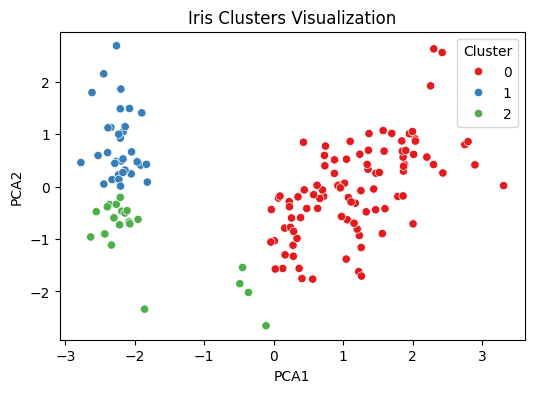

In [9]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

df['PCA1']=X_pca[:,0]
df['PCA2']=X_pca[:,1]

# Plot Clusters
plt.figure(figsize=(6,4))
sns.scatterplot(x='PCA1' , y='PCA2' , hue='Cluster' ,  data=df, palette='Set1')
plt.title("Iris Clusters Visualization")
plt.show()

Cluster Colors

Red dots (Cluster 0) — one group of flowers

Blue dots (Cluster 1) — another group

Green dots (Cluster 2) — third group

The plot shows three distinct clusters, meaning the algorithm successfully grouped the flowers based on similarities in their features.

The red cluster (Cluster 0) is clearly separated from the others — indicating one unique species (likely Iris-setosa).

The blue and green clusters (Clusters 1 and 2) slightly overlap — showing these two species (versicolor and virginica) have more similar feature patterns.

In [10]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.4798814508199817
